In [1]:
import multiprocessing as mp
from functools import partial
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm

import DMdecay as dmd
import JWSTutils as jwst
from gnz11_split import partition_gnz11

In [2]:
run_dir = "gnz11_split"
prev_config_path = F"{run_dir}/gnz11_split.toml"

In [3]:
prev_configs = dmd.prep.parse_configs(prev_config_path)
run_name = prev_configs["run"]["name"]

data = jwst.process_datafiles(prev_configs["run"]["paths"], 
                                prev_configs["system"]["res_path"])
data = partition_gnz11(data, prev_configs["run"]["lambda_min"],
                        prev_configs["run"]["lambda_split"])
for spec in data:
    dmd.prep.doppler_correction(spec, prev_configs["halo"])
    dmd.prep.add_Dfactor(spec, prev_configs["halo"])
    spec["sigma_v"] = prev_configs["halo"]["sigma_v"]

base_specset = dmd.prep.SpecSetfromList(data)

parsing gnz11_split/gnz11_split.toml
processing 2 datafiles...


In [4]:
old_rawlimits = np.loadtxt(
    F"{run_name}/{prev_configs['run']['rawlimits_filename']}")
valid = np.isfinite(old_rawlimits[:, 1])
mass_to_test = old_rawlimits[valid, :][:, 0]
lam_to_test = dmd.conversions.mass_to_wavelength(mass_to_test)
Nlams = lam_to_test.shape[0]
exisitng_limit_invsec = old_rawlimits[valid, :][:, 1]
decayrate_to_test = \
    dmd.conversions.invsec_to_fluxscale(exisitng_limit_invsec)

array([5.62745435e-06, 2.13539415e-05, 7.42320188e-05])

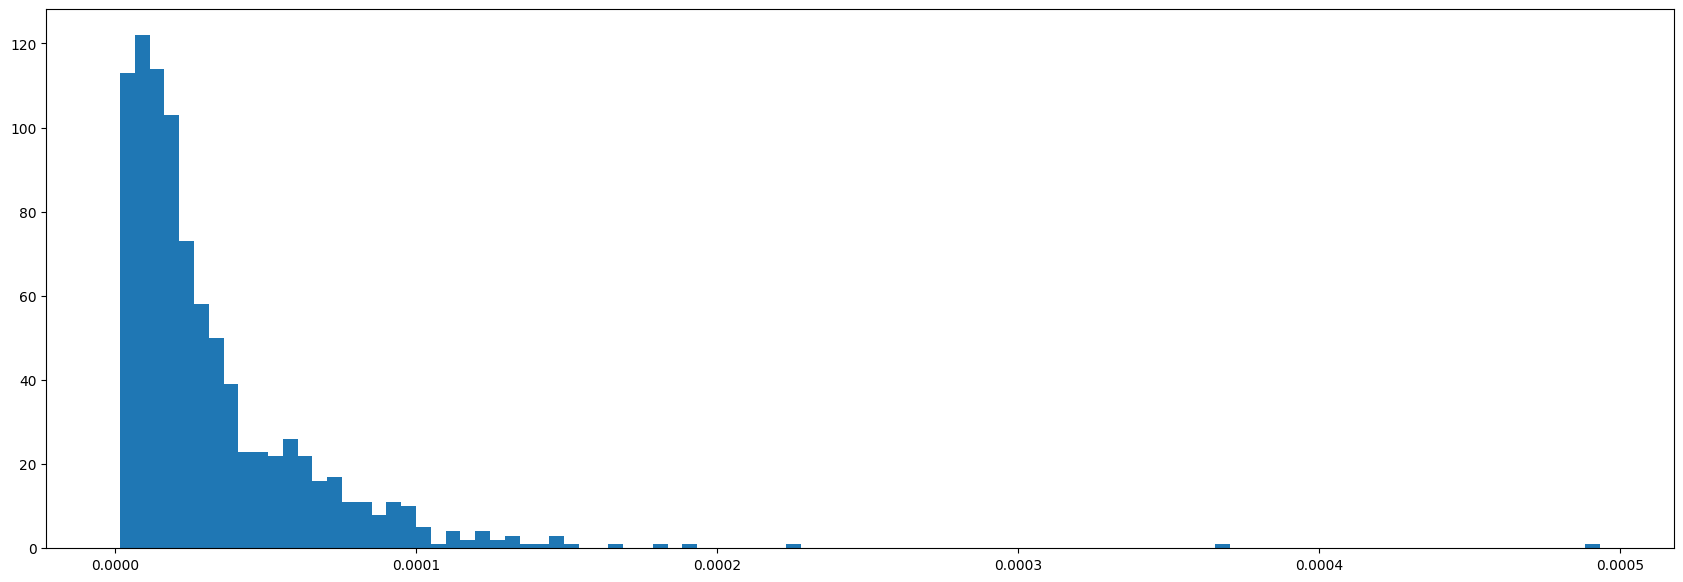

In [5]:
fig, ax = plt.subplots(figsize=(21, 7))
ax.hist(decayrate_to_test, bins=100)
np.quantile(decayrate_to_test, [0.1, 0.5, 0.9])

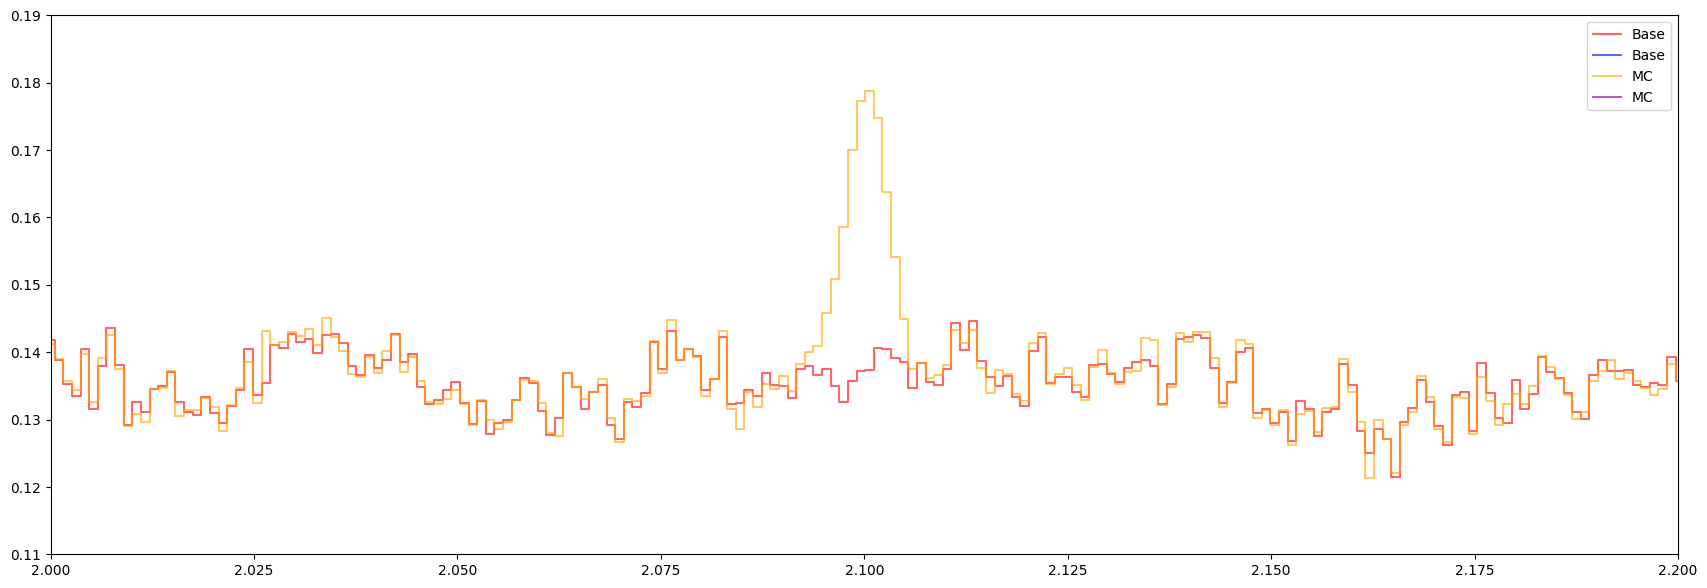

In [23]:
decayrate = 2e-4
lam0 = 2.1

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()

fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.6, label="Base")
new_specset.plot(ax=ax, error_band=0,
             distinct_plot_args=[{"color": "orange"},
                                 {"color": "purple"},],
             alpha=0.6, label="MC")
ax.set_xlim(lam0 - 0.1, lam0 + 0.1)
ax.set_ylim(0.11, 0.19)
ax.legend()

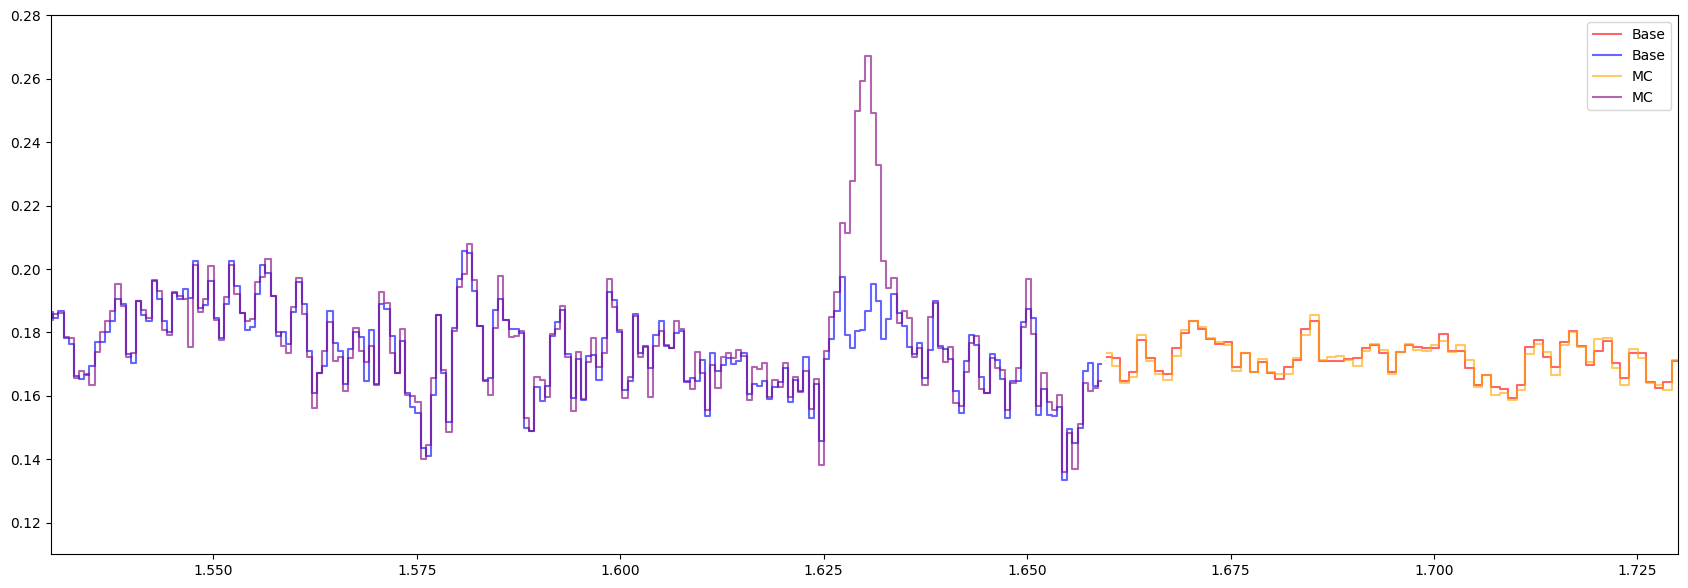

In [25]:
decayrate = 4e-4
lam0 = 1.63

new_specset = base_specset.add_DM_line(decayrate, lam0).resample_flux()

fig, ax = plt.subplots(figsize=(21, 7))
base_specset.plot(ax=ax, error_band=0, 
             distinct_plot_args=[{"color": "red"},
                                 {"color": "blue"}],
             alpha=0.6, label="Base")
new_specset.plot(ax=ax, error_band=0,
             distinct_plot_args=[{"color": "orange"},
                                 {"color": "purple"}],
             alpha=0.6, label="MC")
ax.set_xlim(lam0 - 0.1, lam0 + 0.1)
ax.set_ylim(0.11, 0.28)
ax.legend()

In [ ]:
keys_for_linesearch = {
    "analysis":[
      "width_factor", 
      "padding", 
      "num_knots", 
      "chisq_step", 
      "limit_guess", 
      "max_clip_iters", 
      "clipping_factor", 
      "Ntrials", 
      "Nbins", 
      "power_threshold"],
    "halo":[ 
      "sigma_v"]}
linesearch_configs = {k:prev_configs[k1][k] 
                       for k1, l1 in keys_for_linesearch.items()
                       for k in l1
                       if k in prev_configs[k1].keys()} 
setup = dmd.linesearch.LineSearchSetup(**linesearch_configs)

SpecSet(N_specs=2, flux=[array([0.17109615, 0.17021769, 0.1652778 , ..., 0.03590511, 0.02782997,
       0.017043  ]), array([0.2106194 , 0.21197508, 0.21133659, ..., 0.16999923, 0.16409507,
       0.16804676])], error=[array([0.00154223, 0.001742  , 0.00161864, ..., 0.00143556, 0.00180074,
       0.00493607]), array([0.00223284, 0.00231   , 0.00257533, ..., 0.00551577, 0.00467087,
       0.00497188])], lam=[array([1.65985485, 1.66091442, 1.66197399, ..., 3.16656208, 3.16762165,
       3.16868122]), array([0.98963151, 0.99026726, 0.990903  , ..., 1.65779576, 1.6584315 ,
       1.65906725])], N_pts=array([1425, 1054]), lam_limits=array([[1.65985485, 3.16868122],
       [0.98963151, 1.65906725]]), galactic_coords=array([[ 54.79774432, 125.96364875],
       [ 54.79774432, 125.96364875]]), int_time=array([1896.5557, 1167.1112]), inst_res=array([0.00235407, 0.00140402]), v_rel=array([0.00040657, 0.00040657]), D=array([3.81511685, 3.81511685]), sigma_v=array([0.0005337, 0.0005337]))